In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import matplotlib.patches as mpatches
from statannotations.Annotator import Annotator
from helper_functions import draw_cov_ellipse, ordination_scatterplots
from scipy.stats import ttest_ind, mannwhitneyu, spearmanr

%matplotlib inline

In [2]:
#define source data file
source_path = '~/Desktop/Shenhav Lab/Joint-RPCA/source-data/Supplementary/'

### Fig S1

In [16]:
rpca_res_path = f'{source_path}/Fig_S1/Fig_S1_aitchison.xlsx'
rpca_mod_plt = pd.read_excel(rpca_res_path, sheet_name=None, index_col=0)
rpca_mod_plt.keys()

dict_keys(['Metabolomics', 'Proteomics', 'MetaG', 'MetaT', 'Viromics'])

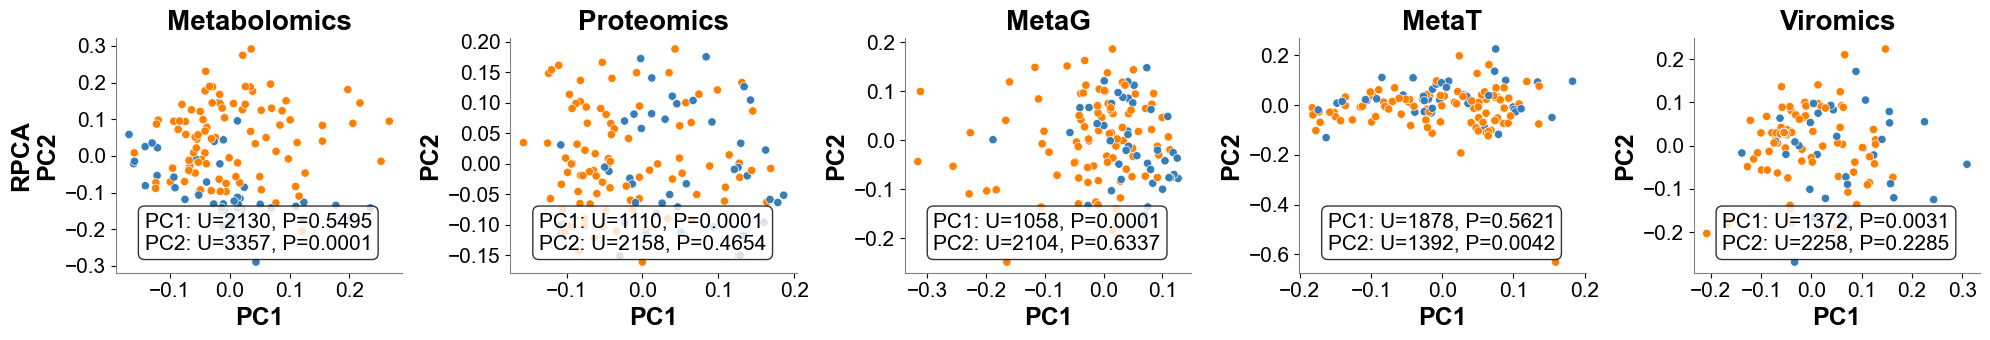

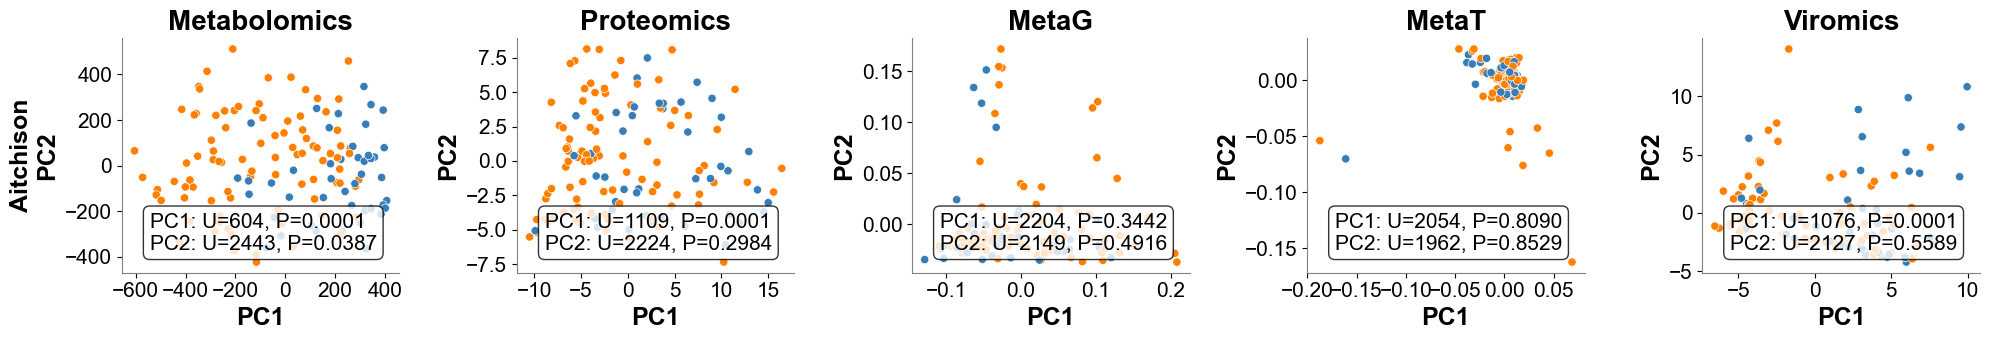

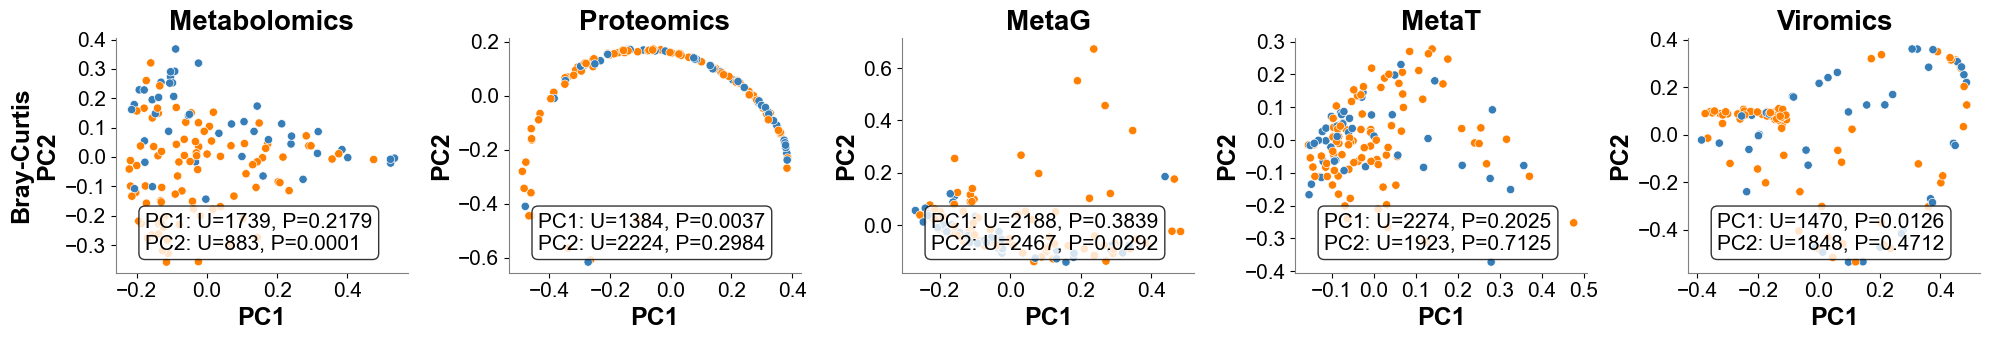

In [17]:
source_cols = ['PC1', 'PC2', 'PC3', 'Participant ID', 'diagnosis_binned']
pal_ =  {'IBD':'#ff7f00', 'nonIBD':'#377eb8'}
lbl_map_two = {'RPCA':'RPCA', 
               'aitchison':'Aitchison', 
               'braycurtis':'Bray-Curtis'}

for method_ in ['RPCA', 'aitchison', 'braycurtis']:

    rpca_res_path = f'{source_path}/Fig_S1/Fig_S1_{method_}.xlsx'
    rpca_mod_plt = pd.read_excel(rpca_res_path, sheet_name=None)
    
    fig, axn = plt.subplots(1, 5, figsize=(20, 3.5))
    
    for ax, omic_ in zip(axn.T.flatten(), rpca_mod_plt.keys()):

        ord_plt = rpca_mod_plt[omic_]
        sns.scatterplot(x='PC1', y='PC2', hue='diagnosis_binned',
                        data=ord_plt, ax=ax, palette=pal_)
        ax.set_xlabel('PC1', fontname='Arial',
                      color='black', weight='bold', fontsize=18)
        ax.set_title(omic_, fontname='Arial', color='black', 
                     weight='bold', fontsize=20)

        if 'Metabolomics' in omic_:
            ax.set_ylabel('{}\nPC2'.format(lbl_map_two[method_]),
                        fontname='Arial', color='black', 
                        weight='bold', fontsize=18)
        else:
            ax.set_ylabel('PC2',fontname='Arial',
                        color='black', weight='bold', fontsize=18)
        
        # fix backround
        ax.set_facecolor('white')
        ax.set_axisbelow(True)
        sns.despine()
        
        for child in ax.get_children():
            if isinstance(child, matplotlib.spines.Spine):
                child.set_color('grey')

        for tick in ax.get_yticklabels():
            tick.set_fontproperties('arial')
            tick.set_color("black")
            tick.set_fontsize(15)
        for tick in ax.get_xticklabels():
            tick.set_fontproperties('arial')
            tick.set_color("black")
            tick.set_fontsize(15)
        ax.legend_.remove()
        
        txt_s = []
        props = dict(boxstyle='round', facecolor='white', alpha=0.8)
        for pc_ in ['PC1','PC2']:
            f_, p_ = mannwhitneyu(ord_plt[ord_plt.diagnosis_binned == 'IBD'].dropna(subset=[pc_])[pc_].values, 
                                ord_plt[ord_plt.diagnosis_binned != 'IBD'].dropna(subset=[pc_])[pc_].values)
            if p_ < 0.0001:
                p_ = 0.0001
            txt_s.append('%s: U=%d, P=%.4f' % (pc_, f_, p_))
        ax.text(0.1, 0.1, '\n'.join(txt_s), 
                fontsize=15, color='black', fontname='Arial', 
                transform=ax.transAxes, bbox=props)
        
    #plt.tight_laout()
    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, 
                        top=0.9, wspace=0.3, hspace=0.3)
    plt.tight_layout()
    plt.show()

### Fig S2

In [ ]:
#load source data
aggregated_metrics = pd.read_csv(f"{source_path}Fig_S2/Fig_S2A_error_dist.csv", index_col=0)

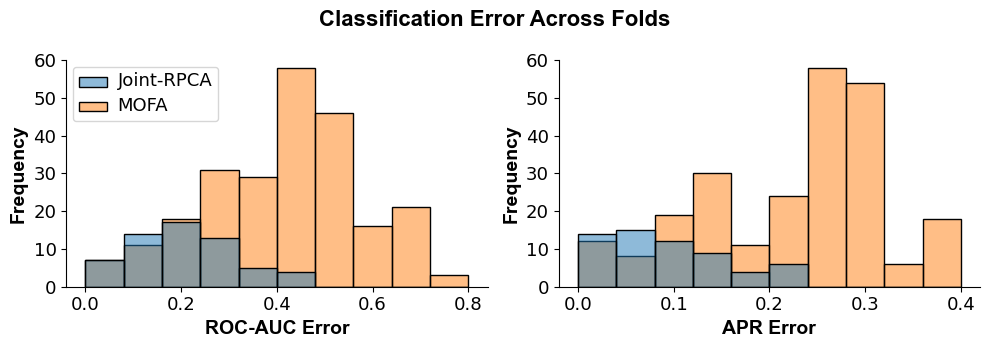

In [ ]:
bins_roc = np.linspace(0, 0.8, 11)
bins_apr = np.linspace(0, 0.4, 11)

fig, axn = plt.subplots(1, 2, figsize=(10, 3.5))
sns.histplot(aggregated_metrics, 
             bins=bins_roc, x='roc_error', hue='method', 
             multiple='layer', stat='count', ax=axn[0])
sns.despine()
axn[0].set_xlabel("ROC-AUC Error", weight='bold', fontsize=14, fontname='Arial')
axn[0].set_ylabel("Frequency", weight='bold', fontsize=14, fontname='Arial')
axn[0].tick_params(axis='x', labelsize=13)
axn[0].tick_params(axis='y', labelsize=13)

leg = axn[0].get_legend()
leg.set_title('')
for t in leg.texts:
    t.set_fontsize(13)
leg.set_loc('upper left')

sns.histplot(aggregated_metrics, 
             bins=bins_apr, x='apr_error', hue='method', 
             multiple='layer', stat='count', ax=axn[1])
sns.despine()
axn[1].set_xlabel("APR Error", weight='bold', fontsize=14, fontname='Arial')
axn[1].set_ylabel("Frequency", weight='bold', fontsize=14, fontname='Arial')
axn[1].legend_.remove()
axn[1].tick_params(axis='x', labelsize=13)
axn[1].tick_params(axis='y', labelsize=13)

#force consistent limits
axn[0].set_ylim(0, 60)
axn[1].set_ylim(0, 60)

plt.suptitle("Classification Error Across Folds", 
             weight='bold', fontsize=16, fontname='Arial')
plt.tight_layout()
plt.show()

In [ ]:
#load source data
mofa_metrics_ = pd.read_csv(f"{source_path}/Fig_S2/Fig_S2B_MOFA_projection_dist.csv", index_col=0)

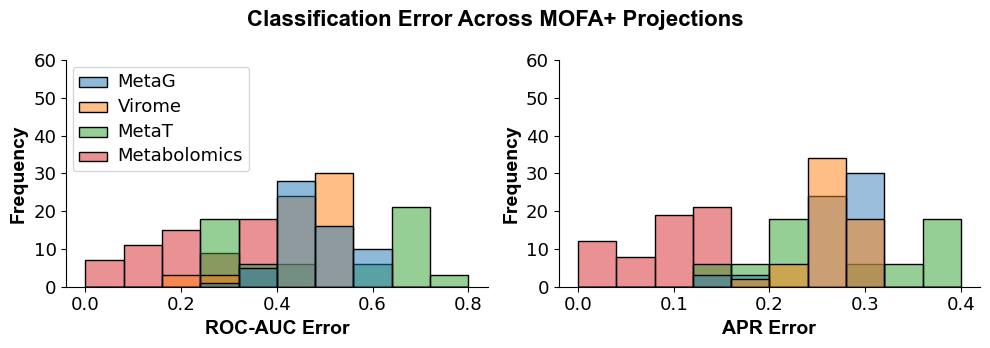

In [44]:
bins_roc = np.linspace(0, 0.8, 11)
bins_apr = np.linspace(0, 0.4, 11)

om_cmap = {'Virome':'#377eb8', 
           'MetaT':'#2ca02c',
           'Metabolomics':'#d62728',
           'MetaG':'#ff7f0e'}

fig, axn = plt.subplots(1, 2, figsize=(10, 3.5))
sns.histplot(mofa_metrics_, bins=bins_roc, x='roc_error', hue='Omic_Title', 
             multiple='layer', stat='count', ax=axn[0])
sns.despine()
axn[0].set_xlabel("ROC-AUC Error", weight='bold', fontsize=14, fontname='Arial')
axn[0].set_ylabel("Frequency", weight='bold', fontsize=14, fontname='Arial')
axn[0].tick_params(axis='x', labelsize=13)
axn[0].tick_params(axis='y', labelsize=13)

leg = axn[0].get_legend()
leg.set_title('')
for t in leg.texts:
    t.set_fontsize(13)
leg.set_loc('upper left')

sns.histplot(mofa_metrics_, bins=bins_apr, x='apr_error', hue='Omic_Title', 
             multiple='layer', stat='count', ax=axn[1], palette=om_cmap)
sns.despine()
axn[1].set_xlabel("APR Error", weight='bold', fontsize=14, fontname='Arial')
axn[1].set_ylabel("Frequency", weight='bold', fontsize=14, fontname='Arial')
axn[1].legend_.remove()
axn[1].tick_params(axis='x', labelsize=13)
axn[1].tick_params(axis='y', labelsize=13)

#force consistent limits
axn[0].set_ylim(0, 60)
axn[1].set_ylim(0, 60)

plt.suptitle("Classification Error Across MOFA+ Projections",
             weight='bold', fontsize=16, fontname='Arial')
plt.tight_layout()
plt.show()

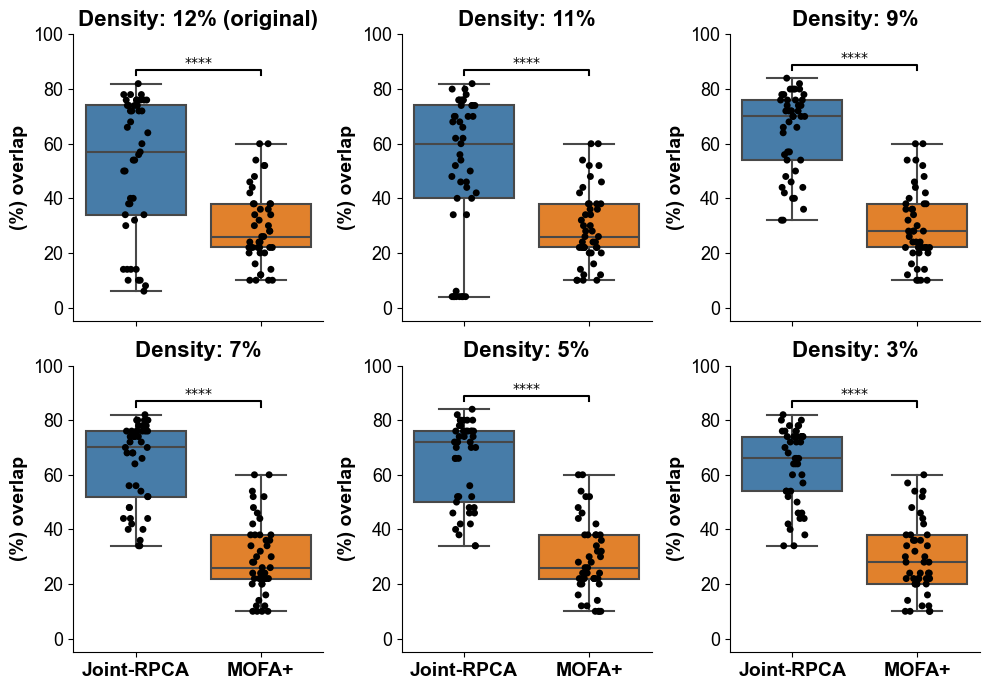

In [ ]:
density_sheets = ["Density_12", "Density_11", "Density_9", "Density_7", "Density_5", "Density_3"]
density_title = {'Density_12': "Density: 12% (original)", 'Density_11': "Density: 11%", 
                 'Density_9': "Density: 9%", 'Density_7': "Density: 7%",
                 'Density_5': "Density: 5%", 'Density_3': "Density: 3%"}

fig, axn = plt.subplots(2, 3, figsize=(10, 7), sharex=True)
axn = axn.flatten()

method_palette = {"Joint-RPCA": "#377eb8",  "MOFA+": "#ff7f0e"}

for sheet_name, ax in zip(density_sheets, axn):

    joint_mat = pd.read_excel(f"{source_path}/Fig_S2/Fig_S2C_Joint-RPCA_overlap.xlsx",
                              sheet_name=sheet_name)

    mofa_mat = pd.read_excel(f"{source_path}/Fig_S2/Fig_S2C_MOFA_overlap.xlsx",
                             sheet_name=sheet_name)

    # lower triangle only (excluding diagonal)
    mask = np.tril(np.ones(joint_mat.shape), k=-1).astype(bool)
    joint_vals = joint_mat.where(mask).stack().values
    mofa_vals = mofa_mat.where(mask).stack().values

    merged_upper_vals = pd.DataFrame({
        "Overlap": np.concatenate([joint_vals, mofa_vals]),
        "Method": (["Joint-RPCA"] * len(joint_vals) +
                   ["MOFA+"] * len(mofa_vals))})

    sns.boxplot(data=merged_upper_vals, x="Method", y="Overlap",
                order=["Joint-RPCA", "MOFA+"], palette=method_palette, ax=ax)

    sns.stripplot(data=merged_upper_vals, x="Method", y="Overlap",
                  order=["Joint-RPCA", "MOFA+"], color="k", ax=ax)

    a_ = merged_upper_vals.loc[merged_upper_vals.Method == "Joint-RPCA", "Overlap"]
    b_ = merged_upper_vals.loc[merged_upper_vals.Method == "MOFA+", "Overlap"]

    U_, p_ = mannwhitneyu(a_, b_)

    x1, x2 = 0, 1
    y = max(a_.max(), b_.max()) + 3
    h = 2

    ax.plot([x1, x1, x2, x2],
            [y, y+h, y+h, y],
            lw=1.5, c="k")

    ax.text((x1+x2)/2, y+h, 
            "****" if p_ < 0.0001 else f"P={p_:.3f}",
            ha="center", va="bottom")
    sns.despine()

    ax.set_title(density_title[sheet_name], fontweight='bold', 
                 fontsize=16, fontname='Arial')
    ax.set_ylabel("(%) overlap", fontsize=14, 
                  fontweight='bold', fontname='Arial')
    ax.set_xlabel("")
    ax.set_ylim(-5, 100)
    
    for tick in ax.get_yticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(13)
    for tick in ax.get_xticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontweight('bold')
        tick.set_fontsize(14)

plt.tight_layout()
plt.show()

### Fig S3

In [4]:
#load RF results
rf_metrics_all = pd.read_csv(f'{source_path}Fig_S3/Fig_S3A_metrics.csv', index_col=0)

In [9]:
omic_title = {'f_100': 'Omic1', 'f_150': 'Omic2', 'f_200': 'Omic3', 
              'All':'All', 'All_MOFA': 'MOFA Full'}

cmap_method = {'Joint-RPCA':'#377eb8', 
                'MOFA':'#ff7f0e', 'MOFA+':'#ff7f0e',
                'mixOmics':'#2ca02c', 'Multiblock sPLS':'#2ca02c',
                'iCluster':'#d62728', 'intNMF':'#9467bd'}

n_induced_idx = [5, 10, 20, 30, 40, 50, 60]

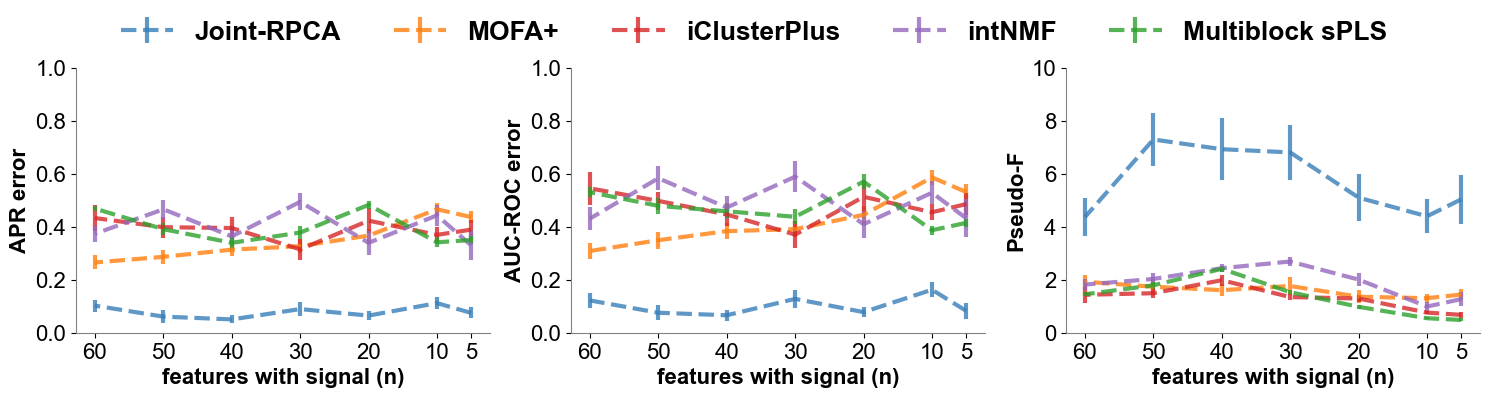

In [10]:
rf_metrics_subset = rf_metrics_all[rf_metrics_all.ninduced!=2].copy()

fig, axn = plt.subplots(1, 3, figsize=(15, 3.5))

for projection_, apr_all_df_subset_ in rf_metrics_subset.groupby('method'):
    rf_metrics_grp = apr_all_df_subset_.groupby('ninduced')
    axn[0].errorbar(rf_metrics_grp.mean(numeric_only=True).index.values,
                    rf_metrics_grp.mean(numeric_only=True)['apr_error'].values,
                    yerr=rf_metrics_grp.sem(numeric_only=True)['apr_error'].values,
                    label=projection_, lw=3, alpha=0.8, ls='--', c=cmap_method[projection_])

    axn[1].errorbar(rf_metrics_grp.mean(numeric_only=True).index.values,
                    rf_metrics_grp.mean(numeric_only=True)['roc_error'].values,
                    yerr=rf_metrics_grp.sem(numeric_only=True)['roc_error'].values,
                    label=projection_, lw=3, alpha=0.8, ls='--', c=cmap_method[projection_])

    axn[2].errorbar(rf_metrics_grp.mean(numeric_only=True).index.values,
                    rf_metrics_grp.mean(numeric_only=True)['f_stat'].values,
                    yerr=rf_metrics_grp.sem(numeric_only=True)['f_stat'].values,
                    label=projection_, lw=3, alpha=0.8, ls='--', c=cmap_method[projection_])
   
axn[0].set_ylabel('APR error', fontname='Arial',
                  color='black', weight='bold', fontsize=16)
axn[1].set_ylabel('AUC-ROC error', fontname='Arial',
                  color='black', weight='bold', fontsize=16)
axn[2].set_ylabel('Pseudo-F', fontname='Arial',
                  color='black', weight='bold', fontsize=16)

for ax in axn:
    ax.invert_xaxis()
    ax.set_xlabel('features with signal (n)',
                  color='black', fontname='Arial',
                  weight='bold', fontsize=16)

    # fix backround
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    sns.despine()
    for child in ax.get_children():
        if isinstance(child, matplotlib.spines.Spine):
            child.set_color('grey')
    for tick in ax.get_yticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(16)
    for tick in ax.get_xticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_horizontalalignment('center')
        tick.set_fontsize(16)

    # make x ticks evenly spaced
    true_densities = [x for x in n_induced_idx if x != 2]
    ax.set_xticks(true_densities)

plt.tight_layout()

# generate legend from last iterations     
handles, labels = axn[2].get_legend_handles_labels()
labels = [l_.replace('MOFA', 'MOFA+') for l_ in labels]
labels = [l_.replace('mixOmics', 'Multiblock sPLS') for l_ in labels]
labels = [l_.replace('iCluster', 'iClusterPlus') for l_ in labels]

legend = axn[0].legend(handles, labels,
                       loc=2, bbox_to_anchor=(0.05, 1.27),
                        prop={'size':19, 'weight':'bold', 'family': 'Arial'},
                        fancybox=False, framealpha=.0,
                        ncol=5, markerscale=1.5)
legend.get_title().set_fontsize('16')

# increase the line width in the legend 
for line in legend.get_lines()[:]:
    line.set_linewidth(4.0)
for line in legend.get_lines()[:]:
    line.set_linewidth(4.0)
    
axn[0].set_ylim(0, 1)
axn[1].set_ylim(0, 1)
axn[2].set_ylim(0, 10)
plt.show()

In [ ]:
#read data
feat_metrics_all = pd.read_csv(f'{source_path}Fig_S3/Fig_S3B_features_with_signal.csv', index_col=0)
feat_metrics_all.head()

,K hits,TP,Precision,Recall,Fold,Induced n,Method
0,10,5,0.500000,0.333333,1,5,Joint-RPCA
1,20,10,0.500000,0.666667,1,5,Joint-RPCA
2,30,13,0.433333,0.866667,1,5,Joint-RPCA
3,40,15,0.375000,1.000000,1,5,Joint-RPCA
4,50,15,0.300000,1.000000,1,5,Joint-RPCA


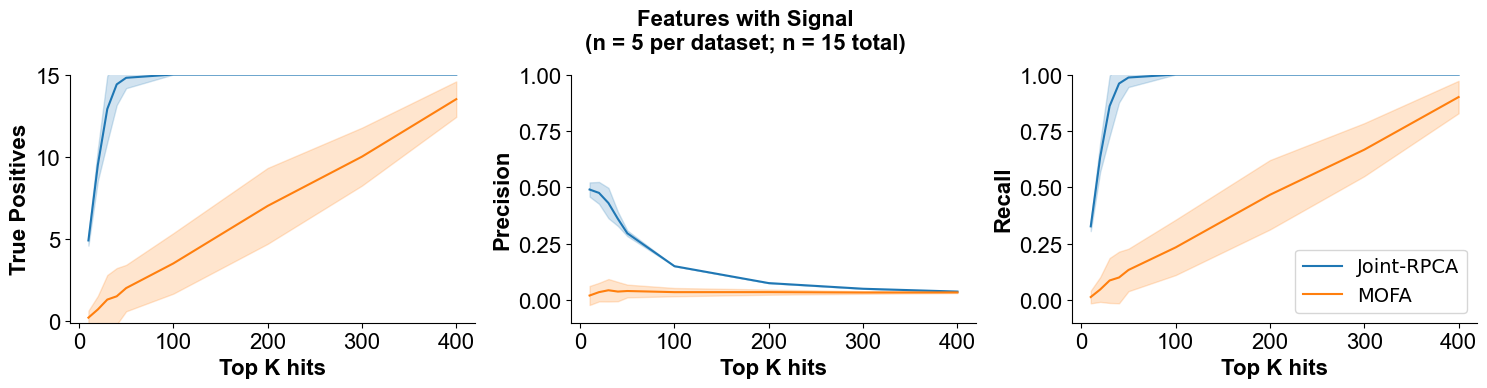

In [13]:
#plot only the subset in manuscript
nf_ = 5
metrics_sub = feat_metrics_all[feat_metrics_all['Induced n']==nf_].copy()

fig, axn = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric_ in zip(axn.flatten(), ['TP', 'Precision', 'Recall']):
    
    sns.lineplot(y=metric_, x='K hits', data=metrics_sub, ax=ax, hue='Method', ci='sd')
    sns.despine()
    
    if metric_ != 'Recall':
        ax.legend_.remove()
    else:
        ax.legend(loc='lower right', fontsize=14)

    ax.set_xlabel('Top K hits', color='black', weight='bold',
                    fontsize=16, fontname='Arial')
    ax.set_ylabel(metric_, color='black', weight='bold', 
                    fontsize=16, fontname='Arial')

    for tick in ax.get_yticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(16)
    for tick in ax.get_xticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_horizontalalignment('center')
        tick.set_fontsize(16)
    ax.locator_params(axis='x', nbins=5)
    ax.locator_params(axis='y', nbins=5)
    
    if metric_ == 'TP':
        ax.set_ylim(-0.1, nf_*3)
        ax.set_ylabel('True Positives', color='black', 
                        weight='bold', fontsize=16, fontname='Arial')
    else:
        ax.set_ylim(-0.1, 1)

plt.suptitle('Features with Signal\n(n = %s per dataset; n = %s total)'%(nf_, nf_*3), 
                fontname='Arial', weight='bold', fontsize=16, y=0.96)
plt.tight_layout()
plt.show()

In [24]:
#load feature ranks and PC information for each fold
joint_rpca_ranks = pd.read_csv(f'{source_path}Fig_S3/Fig_S3C_feature_ranks_Joint-RPCA.csv', index_col=0)
joint_rpca_pcs = pd.read_csv(f'{source_path}Fig_S3/Fig_S3C_best_PCs_Joint-RPCA.csv', index_col=0).reset_index()

mofa_ranks = pd.read_csv(f'{source_path}Fig_S3/Fig_S3C_feature_ranks_MOFA.csv', index_col=0)
mofa_pcs = pd.read_csv(f'{source_path}Fig_S3/Fig_S3C_best_PCs_MOFA.csv', index_col=0).reset_index()

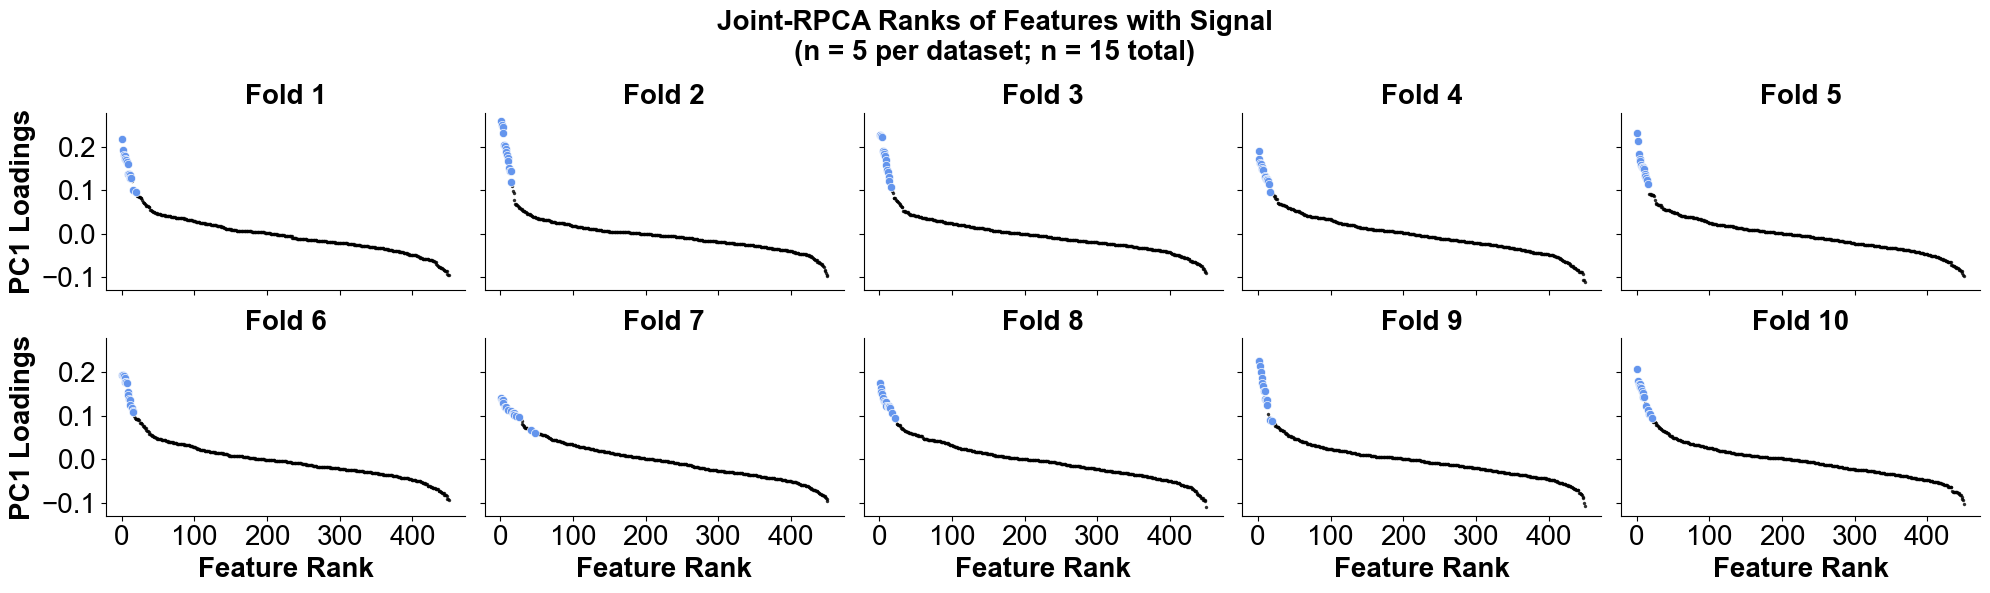

In [32]:
#plotting
n_induced = 5
fig, axn = plt.subplots(2, 5, figsize=(20, 6), sharex=True, sharey=True)

for ax, fold_ in zip(axn.flatten(), range(1, 11)):

    #get fold results and best PC for that fold
    joint_rpca_ranks_fold = joint_rpca_ranks[joint_rpca_ranks.Fold==fold_].copy()
    best_pc = joint_rpca_pcs[joint_rpca_pcs.Fold==fold_]['Best_PC'].values[0]

    best_ranks = joint_rpca_ranks_fold.sort_values(by=best_pc, ascending=False)    
    sns.scatterplot(x='Rank', y=best_pc, s=5, color='black', alpha=0.8,
                    data=best_ranks, ax=ax, edgecolor='k')
    sns.scatterplot(x='Rank', y=best_pc, s=35, color='cornflowerblue', alpha=1,
                    data=best_ranks[best_ranks.induced_signal], ax=ax)
    ax.set_xlabel('Feature Rank', color='black', weight='bold',
                    fontsize=20, fontname='Arial')
    ax.set_ylabel('%s Loadings' % best_pc, fontsize=20, fontweight='bold', fontname='Arial')
    ax.set_title("Fold %s" % fold_, color='black', weight='bold',
                    fontsize=20, fontname='Arial')
    for tick in ax.get_yticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(20)
    for tick in ax.get_xticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_horizontalalignment('center')
        tick.set_fontsize(20)
    ax.locator_params(axis='x', nbins=5)
    ax.locator_params(axis='y', nbins=5)
    sns.despine()

plt.suptitle('Joint-RPCA Ranks of Features with Signal\n(n = %s per dataset; n = %s total)' % (n_induced, n_induced*3),
                fontsize=20, fontname='Arial', weight='bold')
plt.tight_layout()
plt.show()

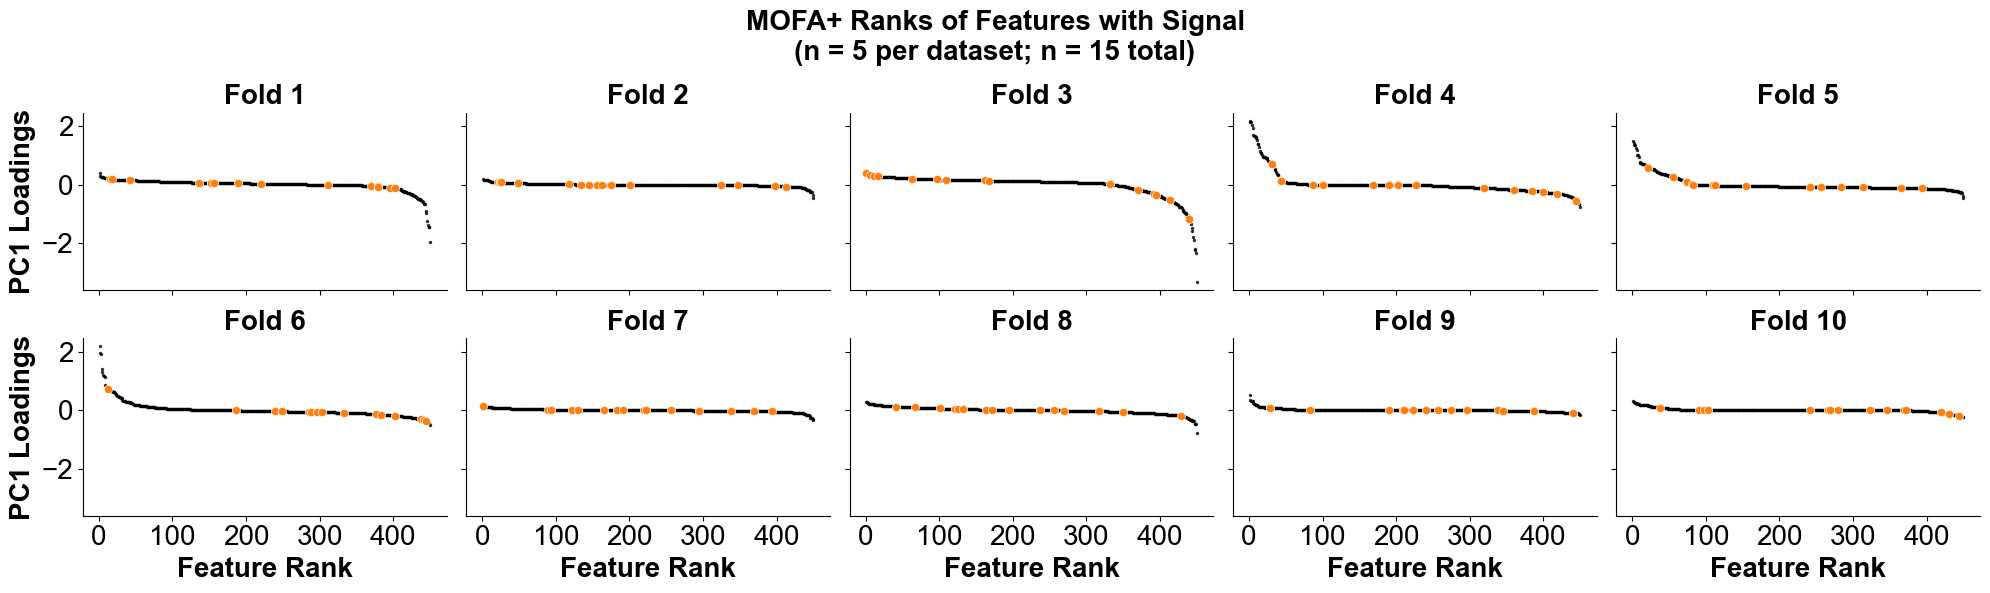

In [34]:
#plotting
n_induced = 5
fig, axn = plt.subplots(2, 5, figsize=(20, 6), sharex=True, sharey=True)

for ax, fold_ in zip(axn.flatten(), range(1, 11)):

    #get fold results and best PC for that fold
    mofa_rpca_ranks_fold = mofa_ranks[mofa_ranks.Fold==fold_].copy()
    best_pc = mofa_pcs[mofa_pcs.Fold==fold_]['Best_PC'].values[0]

    best_ranks = mofa_rpca_ranks_fold.sort_values(by=best_pc, ascending=False)    
    sns.scatterplot(x='Rank', y=best_pc, s=5, color='black', alpha=0.8,
                    data=best_ranks, ax=ax, edgecolor='k')
    sns.scatterplot(x='Rank', y=best_pc, s=35, color='#ff7f0e', alpha=1,
                    data=best_ranks[best_ranks.induced_signal], ax=ax)
    ax.set_xlabel('Feature Rank', color='black', weight='bold',
                    fontsize=20, fontname='Arial')
    ax.set_ylabel('%s Loadings' % best_pc, fontsize=20, fontweight='bold', fontname='Arial')
    ax.set_title("Fold %s" % fold_, color='black', weight='bold',
                    fontsize=20, fontname='Arial')
    for tick in ax.get_yticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(20)
    for tick in ax.get_xticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_horizontalalignment('center')
        tick.set_fontsize(20)
    ax.locator_params(axis='x', nbins=5)
    ax.locator_params(axis='y', nbins=5)
    sns.despine()

plt.suptitle('MOFA+ Ranks of Features with Signal\n(n = %s per dataset; n = %s total)' % (n_induced, n_induced*3),
             fontsize=20, fontname='Arial', weight='bold')
plt.tight_layout()
plt.show()

### Fig S4

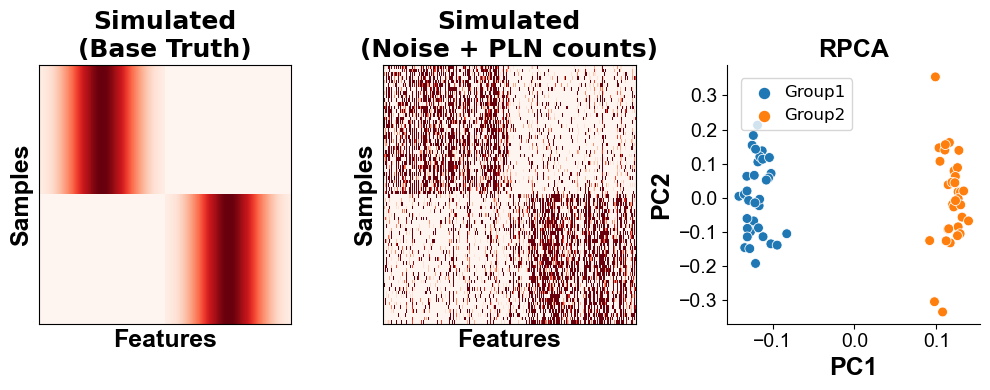

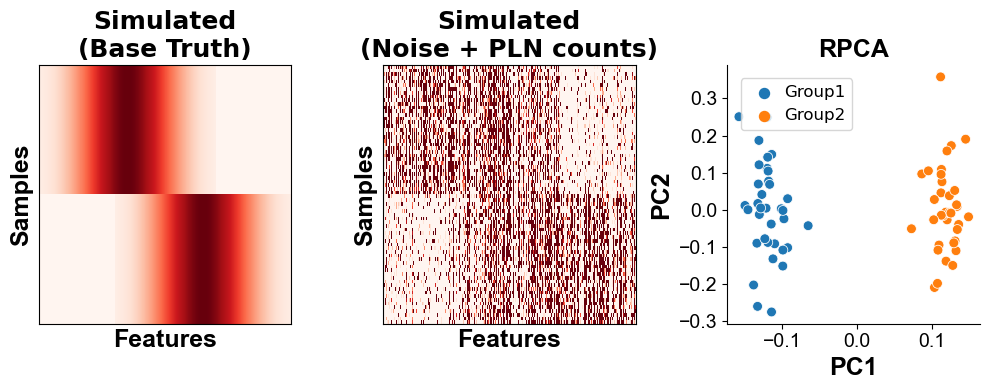

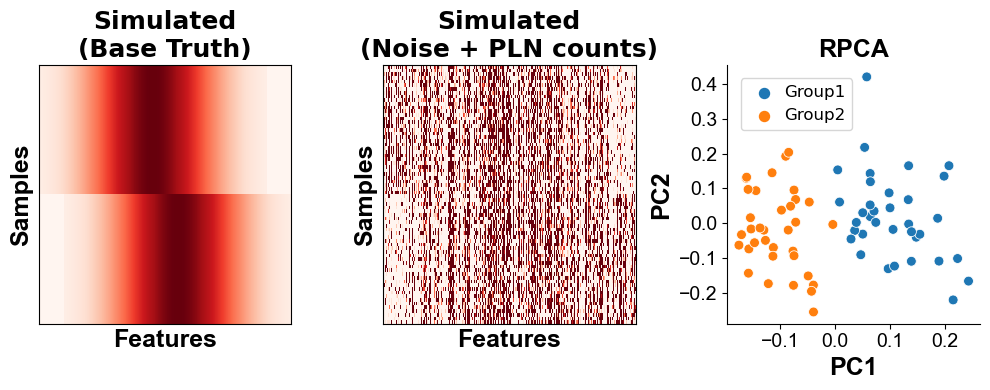

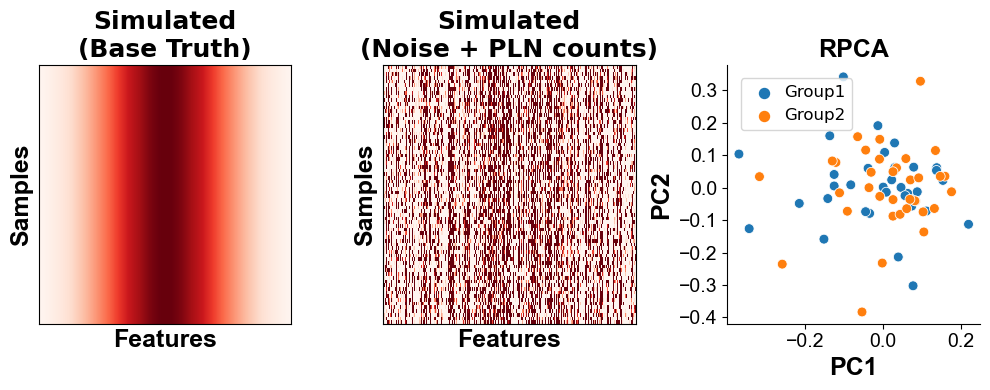

In [43]:
fig_data_ids = ["Fig_S4A_sim_data1_RPCA.xlsx", "Fig_S4A_sim_data2_RPCA.xlsx", 
                "Fig_S4A_sim_data3_RPCA.xlsx", "Fig_S4A_sim_data4_RPCA.xlsx"]

for f_id in fig_data_ids:

    base_truth = pd.read_excel(f"{source_path}/Fig_S4/{f_id}", sheet_name="base_truth", index_col=0)
    sim_data = pd.read_excel(f"{source_path}/Fig_S4/{f_id}", sheet_name="sim_data", index_col=0)
    rpca_results = pd.read_excel(f"{source_path}/Fig_S4/{f_id}", sheet_name="rpca_results", index_col=0)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4))

    ax1.imshow(base_truth.values, cmap="Reds", 
               aspect="auto", interpolation="nearest")

    ax2.imshow(sim_data.values, cmap="Reds",
               aspect="auto", interpolation="nearest", vmax=10)

    sns.scatterplot(data=rpca_results, x="PC1", y="PC2",
                    hue="groups", s=50, ax=ax3)

    ax1.set_title('Simulated\n(Base Truth)', color='black', weight='bold', fontsize=18)
    ax2.set_title('Simulated\n(Noise + PLN counts)', weight='bold', color='black', fontsize=18)
    ax3.set_title('RPCA', color='black', weight='bold', fontsize=18, fontname='Arial')
    ax3.set_ylabel('PC2', color='black', weight='bold', fontsize=18, fontname='Arial')
    ax3.set_xlabel('PC1', color='black', weight='bold', fontsize=18, fontname='Arial')

    for ax in [ax1, ax2]:
        plt.setp(ax.get_xticklabels(), visible=False)
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.tick_params(axis='both', which='both', length=0)
        ax.set_ylabel('Samples', color='black', weight='bold', fontsize=18, fontname='Arial')
        ax.set_xlabel('Features', color='black', weight='bold', fontsize=18, fontname='Arial')

    ax = ax3
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    sns.despine(ax=ax)

    for child in ax.get_children():
        if isinstance(child, matplotlib.spines.Spine):
            child.set_color('black')
            
    for tick in ax.get_xticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(14)
    for tick in ax.get_yticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(14)

    #increase legend font size
    handles, labels = ax.get_legend_handles_labels()
    legend = ax.legend(handles, ['Group1', 'Group2'], loc='upper left', 
                        prop={'size':12}, borderaxespad=0.8,
                        title="", handletextpad=0.2,
                        fancybox=True, framealpha=.8,
                        ncol=1, markerscale=1.2)

    plt.tight_layout()
    plt.show()

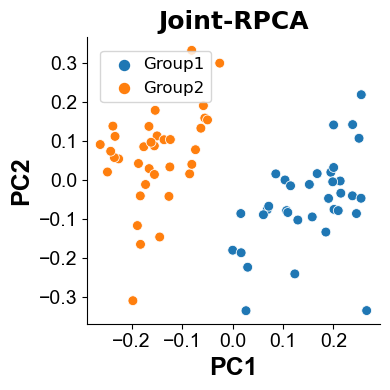

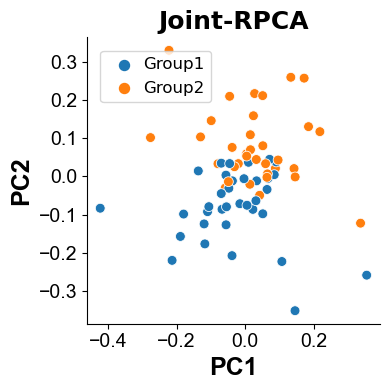

In [48]:
# read Joint-RPCA results
joint_fp = "Fig_S4A_sim_data_Joint-RPCA.xlsx"
ord1 = pd.read_excel(f"{source_path}/Fig_S4/{joint_fp}", sheet_name="ordination_res1", index_col=0)
ord2 = pd.read_excel(f"{source_path}/Fig_S4/{joint_fp}", sheet_name="ordination_res2", index_col=0)

for ord_ in [ord1, ord2]:
    fig, ax = plt.subplots(figsize=(4,4))

    sns.scatterplot(data=ord_, x="PC2", y="PC1", hue="groups", s=50, ax=ax)
    sns.despine()

    ax.set_title('Joint-RPCA', color='black', weight='bold', fontsize=18)
    ax.set_ylabel('PC2', color='black', weight='bold', fontsize=18, fontname='Arial')
    ax.set_xlabel('PC1', color='black', weight='bold', fontsize=18, fontname='Arial')

    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    sns.despine()

    for child in ax.get_children():
        if isinstance(child, matplotlib.spines.Spine):
            child.set_color('black')
    
    for tick in ax.get_xticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(14)
    for tick in ax.get_yticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(14)

    handles, labels = ax.get_legend_handles_labels()
    legend = ax.legend(handles, ['Group1', 'Group2'], loc='upper left', 
                        prop={'size':12}, borderaxespad=0.8,
                        title="", handletextpad=0.2,
                        fancybox=True, framealpha=.8,
                        ncol=1, markerscale=1.2)

    plt.tight_layout()
    plt.show()

In [53]:
# load correlation results
es_compare_df = pd.read_csv(f"{source_path}/Fig_S4/Fig_S4B-C_correlations.csv", index_col=0)
es_compare_df.head()

,fold,es_one,es_two,fes_one,fes_two,joint_es,corr,corr_std,maxf,number_features,feature_multiple
0,0,0.1,0.1,7.856857,7.856857,7.856857,0.999966,5.046813e-06,7.856857,20,1
1,0,0.1,0.2,7.856857,5.753848,7.624772,1.000000,2.548388e-08,6.805353,20,1
2,0,0.1,0.3,7.856857,1.833056,6.680742,1.000000,6.137332e-08,4.844956,20,1
3,0,0.1,0.5,7.856857,0.763322,4.279499,1.000000,3.160883e-09,4.310089,20,1
4,1,0.1,0.1,8.778268,8.778268,8.778268,0.999962,5.813909e-06,8.778268,20,1


SignificanceResult(statistic=0.8406015037593983, pvalue=3.483775929626355e-06)


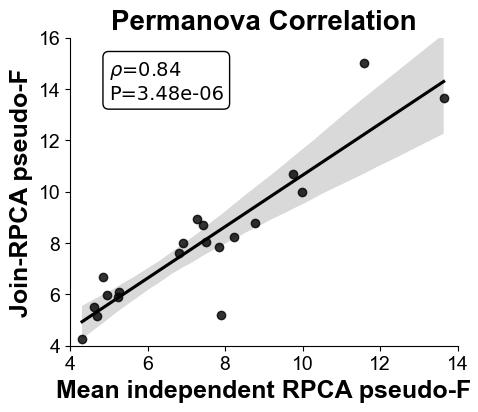

In [54]:
es_compare_df_plt = es_compare_df.copy().dropna(subset=['joint_es'])

fig, ax = plt.subplots(1,1, figsize=(5, 4))

sns.regplot(x='maxf', y='joint_es', data=es_compare_df_plt, color='black', ax=ax)

ax.set_title('Permanova Correlation', 
             color='black', weight='bold', 
             fontsize=20, fontname='Arial')
ax.set_ylabel('Join-RPCA pseudo-F', 
              color='black', weight='bold', 
              fontsize=18, fontname='Arial')
ax.set_xlabel('Mean independent RPCA pseudo-F', 
              color='black', weight='bold', 
              fontsize=18, fontname='Arial')

ax.set_facecolor('white')
ax.set_axisbelow(True)
sns.despine()

for child in ax.get_children():
    if isinstance(child, matplotlib.spines.Spine):
        child.set_color('black')

for tick in ax.get_xticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(14)
for tick in ax.get_yticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(14)

ax.set_ylim(4, 16)
ax.set_xlim(4, 14)

print(spearmanr(es_compare_df_plt.maxf, es_compare_df_plt.joint_es))
rho, p = spearmanr(es_compare_df_plt.maxf, es_compare_df_plt.joint_es)
p = str(p)[:4] + str(p)[str(p).index('e'):]
sts_box = "$\\rho$=%.2f\nP=%s" % (rho, p)
props = dict(boxstyle='round', facecolor='none', edgecolor='black')
ax.text(0.1, 0.8, sts_box, transform=ax.transAxes, bbox=props, ha='left', fontsize=14)

plt.show()

/opt/anaconda3/envs/joint-rpca-benchmarking-flex/lib/python3.9/site-packages/seaborn/categorical.py:1296: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


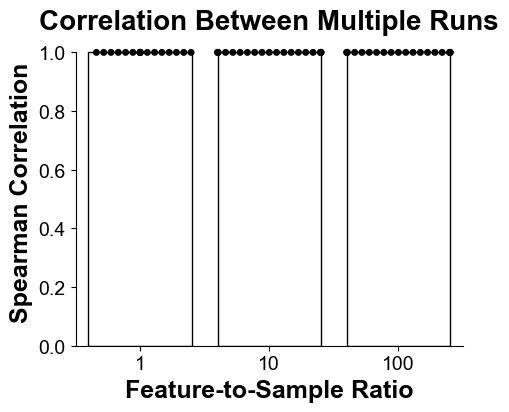

In [55]:
fig, ax = plt.subplots(1,1, figsize=(5, 4))

sns.swarmplot(x='feature_multiple', y='corr', color='black', s=5, data=es_compare_df, ax=ax)
sns.barplot(x='feature_multiple', y='corr', color='white', data=es_compare_df, ax=ax)

for patch in ax.patches:
    clr = patch.get_facecolor()
    patch.set_edgecolor('black')

ax.set_title('Correlation Between Multiple Runs', 
             color='black', weight='bold', 
             fontsize=20, fontname='Arial')
ax.set_ylabel('Spearman Correlation', 
              color='black', weight='bold', 
              fontsize=18, fontname='Arial')
ax.set_xlabel('Feature-to-Sample Ratio', 
              color='black', weight='bold', 
              fontsize=18, fontname='Arial')

ax.set_facecolor('white')
ax.set_axisbelow(True)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_visible(False)

for child in ax.get_children():
    if isinstance(child, matplotlib.spines.Spine):
        child.set_color('black')

for tick in ax.get_xticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(14)
for tick in ax.get_yticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(14)

ax.spines['left'].set_bounds(0, 1)
plt.show()

### Fig S5

In [17]:
biocrust_med_density = pd.read_csv(f'{source_path}/Fig_S5/medium_density_metrics.csv', index_col=0)

/var/folders/wc/r9njmvn106j5gvr496l3xw65jl16p6/T/ipykernel_55240/2199890611.py:52: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


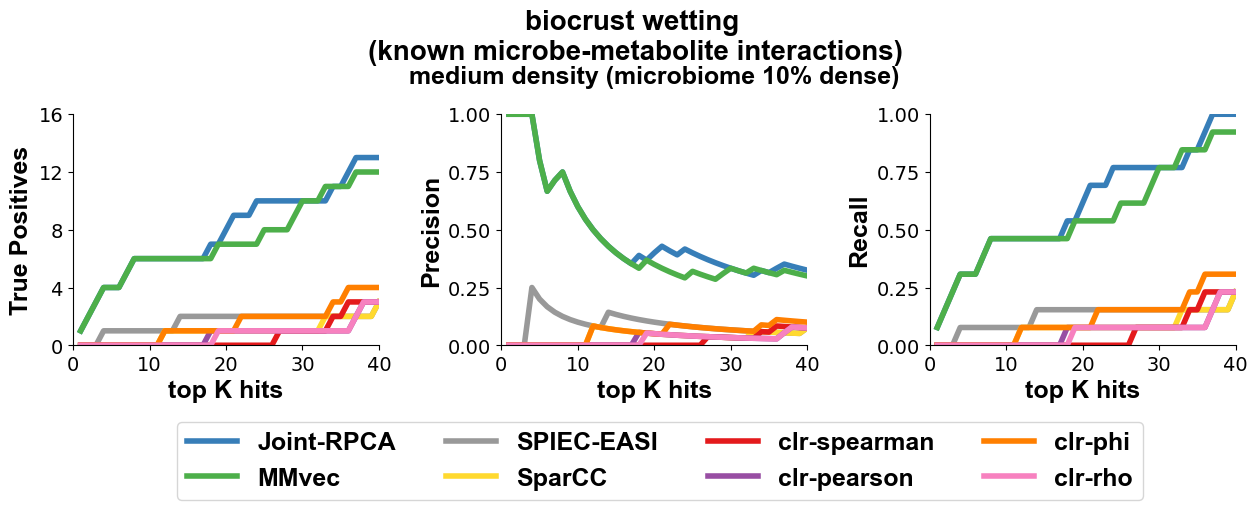

In [ ]:
cmap_ = {'Joint-RPCA':'#377eb8', "MMvec":'#4daf4a',
         'spearman':'#e41a1c', 'pearson':'#984ea3',
         'phi':'#ff7f00', 'rho':'#f781bf',
         'SPIEC-EASI':'#999999', 'SparCC':'#ffd92f'}

fig, axn = plt.subplots(1, 3, figsize=(15, 3), sharex=True)
tbl_ = biocrust_med_density.copy()
labels = ['True Positives', 'Precision', 'Recall']

for ax, metric_, ylim_, label_ in zip(axn.flatten(), ['TP', 'precision', 'recall'], 
                                      [16, 1, 1], labels):

    def plot_stats(ax, attr='F score'):    
        ax.plot(tbl_[tbl_.method=='joint-rpca'][attr], label='Joint-RPCA', lw=4, c=cmap_['Joint-RPCA'])
        ax.plot(tbl_[tbl_.method=='mmvec'][attr], label='MMvec', lw=4, c=cmap_['MMvec'])
        ax.plot(tbl_[tbl_.method=='SPIEC-EASI'][attr], label='SPIEC-EASI', lw=4, c=cmap_['SPIEC-EASI'])
        ax.plot(tbl_[tbl_.method=='SparCC'][attr], label='SparCC', lw=4, c=cmap_['SparCC'])
        ax.plot(tbl_[tbl_.method=='spearman'][attr], label='clr-spearman', lw=4, c=cmap_['spearman'])
        ax.plot(tbl_[tbl_.method=='pearson'][attr], label='clr-pearson', lw=4, c=cmap_['pearson'])
        ax.plot(tbl_[tbl_.method=='phi'][attr], label='clr-phi', lw=4, c=cmap_['phi'])
        ax.plot(tbl_[tbl_.method=='rho'][attr], label='clr-rho', lw=4, c=cmap_['rho'])
        ax.set_ylabel(attr, color='black', weight='bold', fontsize=18, fontname='Arial')
        ax.tick_params(axis="x", labelsize=14)
        ax.tick_params(axis="y", labelsize=14)
        ax.xaxis.set_major_locator(plt.MaxNLocator(4))
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))

    plot_stats(ax, attr=metric_)
    ax.set_ylabel(label_, fontsize=18, weight='bold', fontname='Arial')
    ax.set_xlabel('top K hits', weight='bold', fontsize=18, fontname='Arial')
    ax.set_xticks(np.arange(0, 40+1, 10))
    ax.set_xlim(0, 40)
    ax.set_ylim(0, ylim_)
    sns.despine()
    
    if metric_ == 'TP':
        handles, labels = ax.get_legend_handles_labels()
        legend = ax.legend(handles[:8], labels[:8], loc='center left', 
                            bbox_to_anchor=(0.3, -0.5), ncol=4, 
                            fontsize=14, prop={'size':18, 'weight':'bold', 
                                               'family':'Arial'},)
    
    if metric_ == 'precision':
        ax.set_title('medium density (microbiome 10% dense)', y=1.1, color='black', 
                     weight='bold', fontsize=18, fontname='Arial')
    
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.suptitle('biocrust wetting \n(known microbe-metabolite interactions)',
             color='black', weight='bold', fontname='Arial',
             fontsize=20, y=1.23)
plt.tight_layout()
plt.show()

### Fig S6

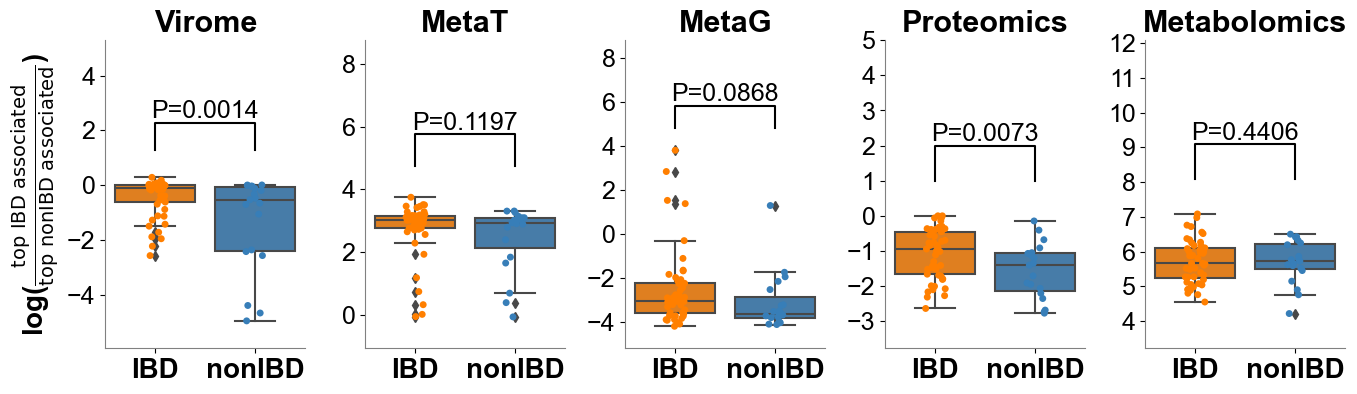

In [ ]:
pal_ =  {'IBD':'#ff7f00', 'nonIBD':'#377eb8'}
omic_order = ['Virome', 'MetaT', 'MetaG', 'Proteomics', 'Metabolomics']

fig, axn = plt.subplots(1, len(omic_order), figsize=(16, 4), 
                        sharex=True, sharey=False)
axn = axn.flatten()

for ax , omic_ in zip(axn, omic_order):

    # load data
    rpca_lr_ = pd.read_csv(f'{source_path}Fig_S6/Fig_S6_RPCA_{omic_}_log_ratios.csv', index_col=0)
    
    sns.boxplot(y='log_ratio', x='diagnosis_binned', data=rpca_lr_, ax=ax, palette=pal_)
    sns.stripplot(y='log_ratio', x='diagnosis_binned', data=rpca_lr_, ax=ax, palette=pal_)
    ax.set_title(omic_, color='black', weight='bold', fontsize=22, fontname='Arial')
    
    # statistical annotation
    a_ = rpca_lr_[rpca_lr_.diagnosis_binned != 'nonIBD']['log_ratio'].dropna()
    b_ = rpca_lr_[rpca_lr_.diagnosis_binned == 'nonIBD']['log_ratio'].dropna()
    U_, p_ = ttest_ind(b_, a_, alternative='less')
    x1, x2 = 0, 1
    y, h, col = np.max([np.max(a_), np.max(b_)]) + 1, 1, 'k'
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
    ax.text((x1+x2)*.5, y+h, "P=%.4f" %(p_), ha='center',
            va='bottom', color=col, fontsize=18, fontname='Arial')
    ax.set_ylim(np.min([np.min(a_), np.min(b_)]) - 1,
            np.max([np.max(a_), np.max(b_)]) + 5)

for ax in axn:
    ax.set_xlabel('', color='black', weight='bold', fontsize=18, fontname='Arial')
    ax.set_ylabel('', color='black', weight='bold', fontsize=18, fontname='Arial')

    # fix backround
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['top'].set_visible(False)
    for child in ax.get_children():
        if isinstance(child, matplotlib.spines.Spine):
            child.set_color('grey')

    for tick in ax.get_yticklabels():
        tick.set_fontproperties('arial')
        tick.set_color("black")
        tick.set_fontsize(18)
    for tick in ax.get_xticklabels():
        tick.set_fontproperties('arial')
        tick.set_weight('bold')
        tick.set_color("black")
        tick.set_fontsize(20)

axn[0].set_ylabel('log($\\frac{\\mathrm{top\,\,IBD\,\,associated}}{\\mathrm{top\,\,nonIBD\,\,associated}}$)',
                  fontname='Arial', color='black', weight='bold', fontsize=20)
        
plt.subplots_adjust(wspace=0.3)
plt.show()

### Fig S7

In [5]:
network_links = pd.read_csv(f'{source_path}/Fig_S7/Fig_S7_network.csv', index_col=0)

In [12]:
color_map = {'Metabolites': '#CF9FFF',
             'Bacterial Genomes (MetaG)': '#FF7518',
             'Functions (MetaG)': '#50C878',
             'Eukaryotes (18S)': '#FF0000'}
feature_color_map = pd.read_csv(f'{source_path}/Fig_S7/Fig_S7_color_map.csv', index_col=0)
modality_map = dict(zip(feature_color_map.Feature_ID, feature_color_map.Omic_ID))

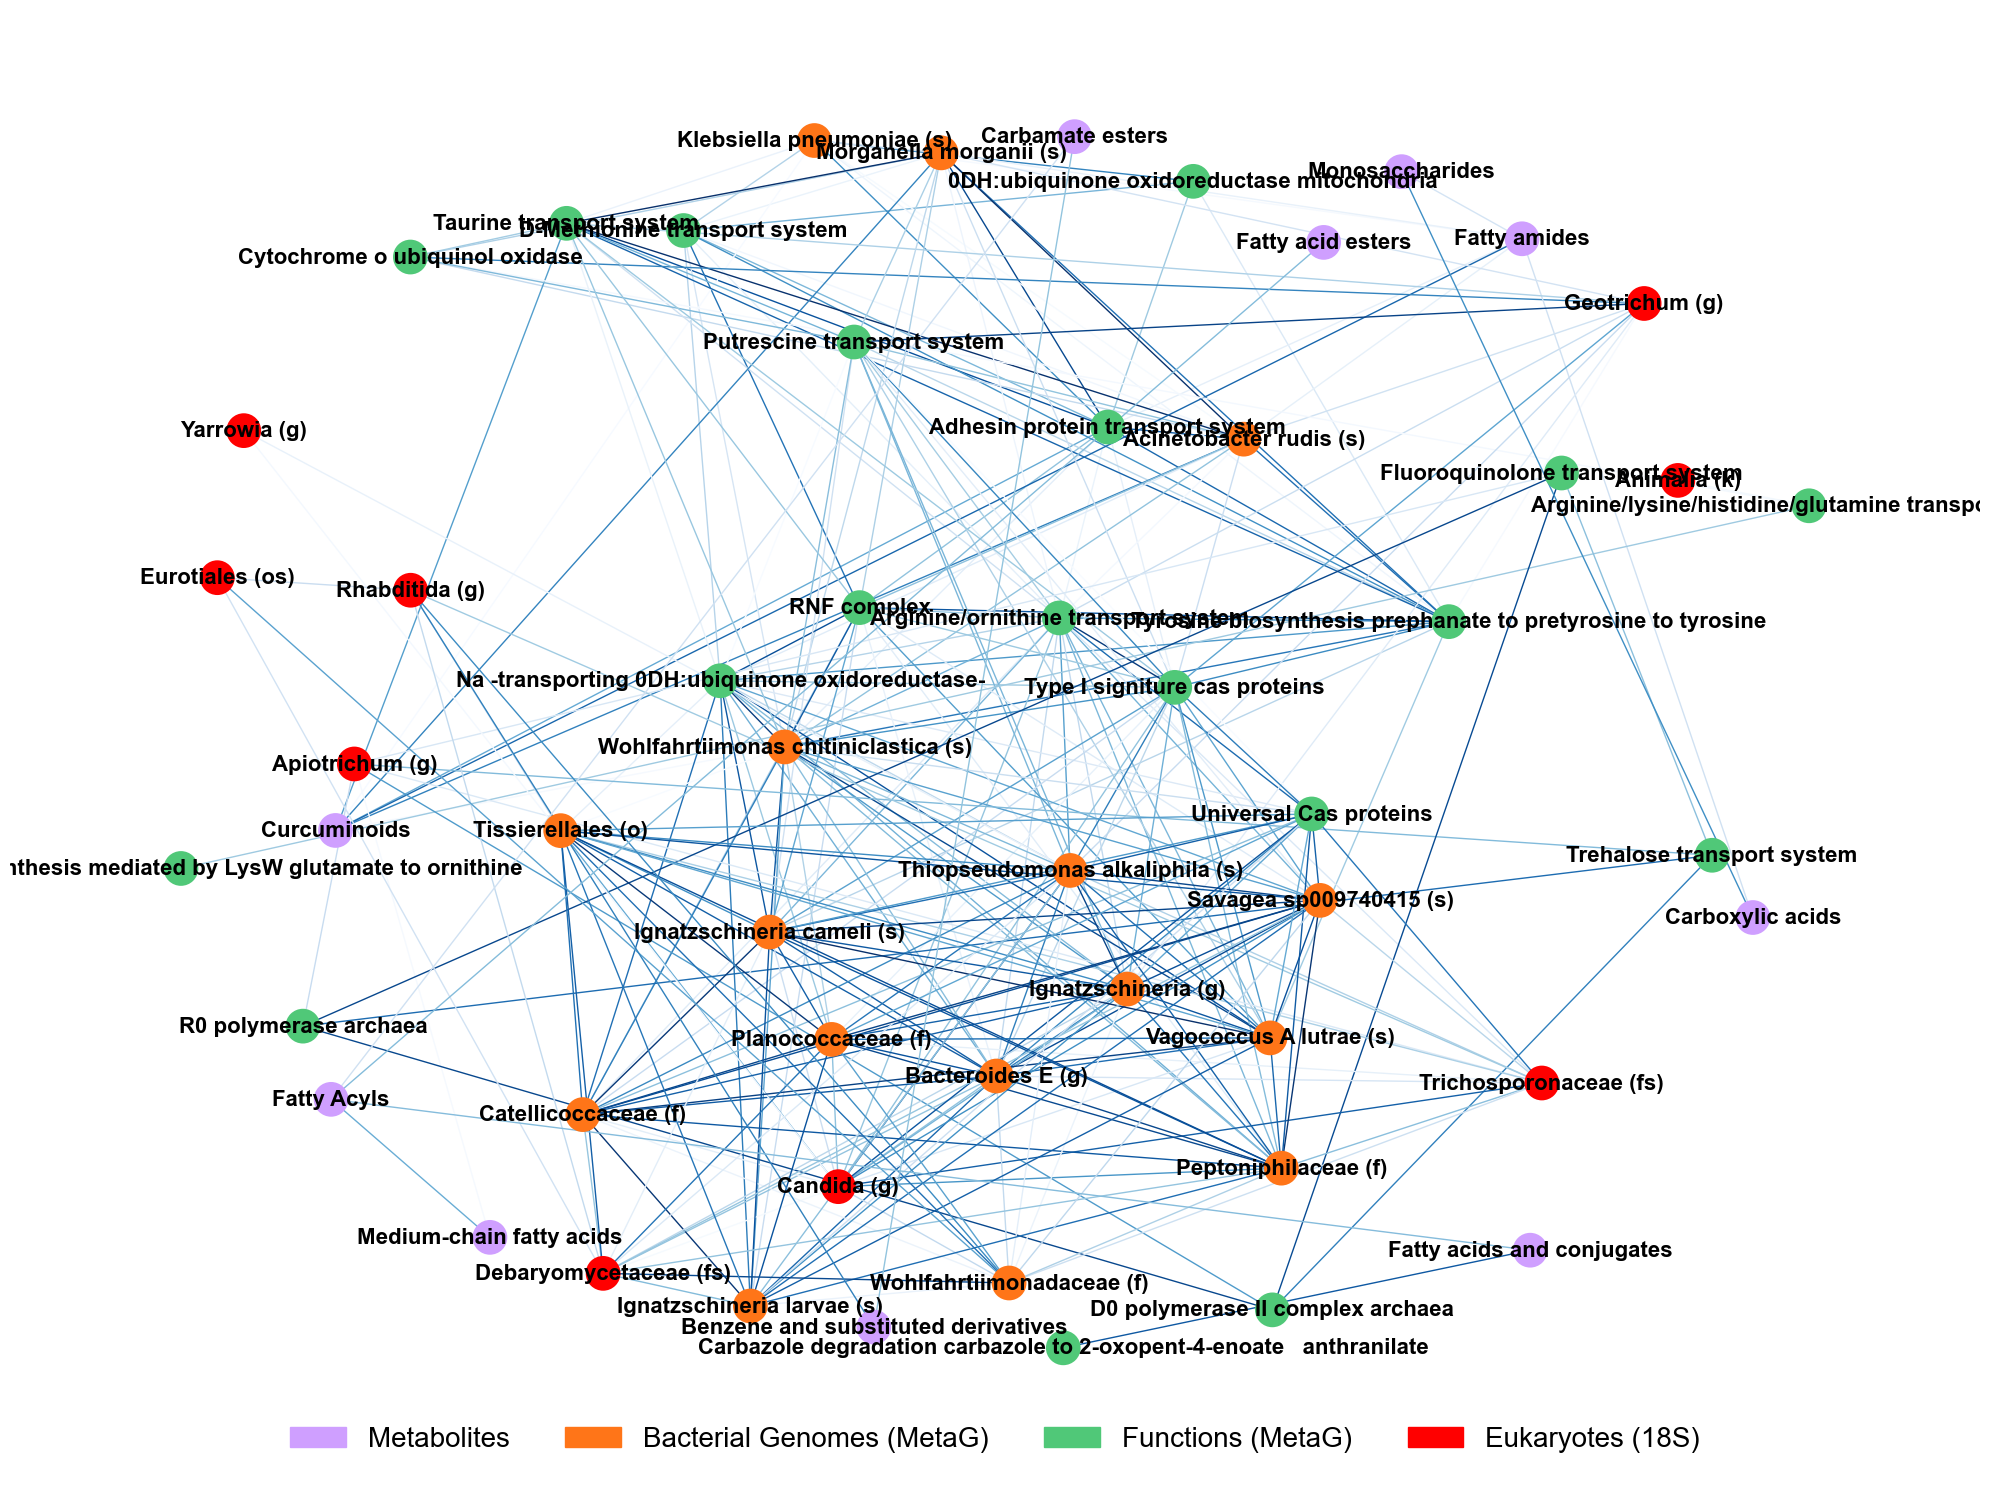

In [ ]:
# Build your graph
G = nx.from_pandas_edgelist(network_links, 'var1', 'var2')

# Plot the network:
values = range(network_links.shape[0])
pos = nx.spring_layout(G, k=1.8, seed=0)

fig, ax = plt.subplots(1, 1, figsize=(20, 15)) 
y_off = 3

nx.draw(G, with_labels=True,
        pos = {k:([v[0], v[1]+y_off]) for k,v in pos.items()},
        node_color=[color_map[modality_map[node[0]]]
                    for node in G.nodes(data=True)], 
        node_size=400,
        edge_color=[abs(network_links[(network_links.var1==v) &
                                      (network_links.var2==u)]['value'].values[0])
                    for u, v in G.edges],
        edge_cmap= plt.cm.Blues, linewidths=5, width=1, 
        font_size=16, font_family='arial', font_weight='bold', 
        ax=ax)


handles_ = [mpatches.Patch(color=c_, label=modality_) for modality_, c_ in color_map.items()]
legend = ax.legend(handles=handles_, loc='upper center', bbox_to_anchor=(0.5, 0.05),
            prop={'size':20, 'family':'Arial'},
            title="", fancybox=True, framealpha=.0,
            ncol=4, markerscale=1.5)
legend.get_title().set_fontsize('20')
# increase the line width in the legend 
for line in legend.get_lines()[:]:
    line.set_linewidth(2.0)
for line in legend.get_lines()[:]:
    line.set_linewidth(2.0)

plt.tight_layout()
plt.show()

### Fig S8

In [ ]:
#save source data
title_save = {'mag': 'MAG', '18S': '18S', 'gene': 'Gene', '16S': '16S',
              'metabolomics': 'Metabolomics', 'gene_module': 'Gene Module'}

rpca_out_ = f'{source_path}/Fig_S8/Fig_S8_rpca_ordinations.xlsx'
rpca_plots_ = pd.read_excel(rpca_out_, sheet_name=None, index_col=0)
rpca_plots_.keys()

dict_keys(['MAG', '18S', 'Metabolomics', 'Gene Module', 'Gene', '16S'])

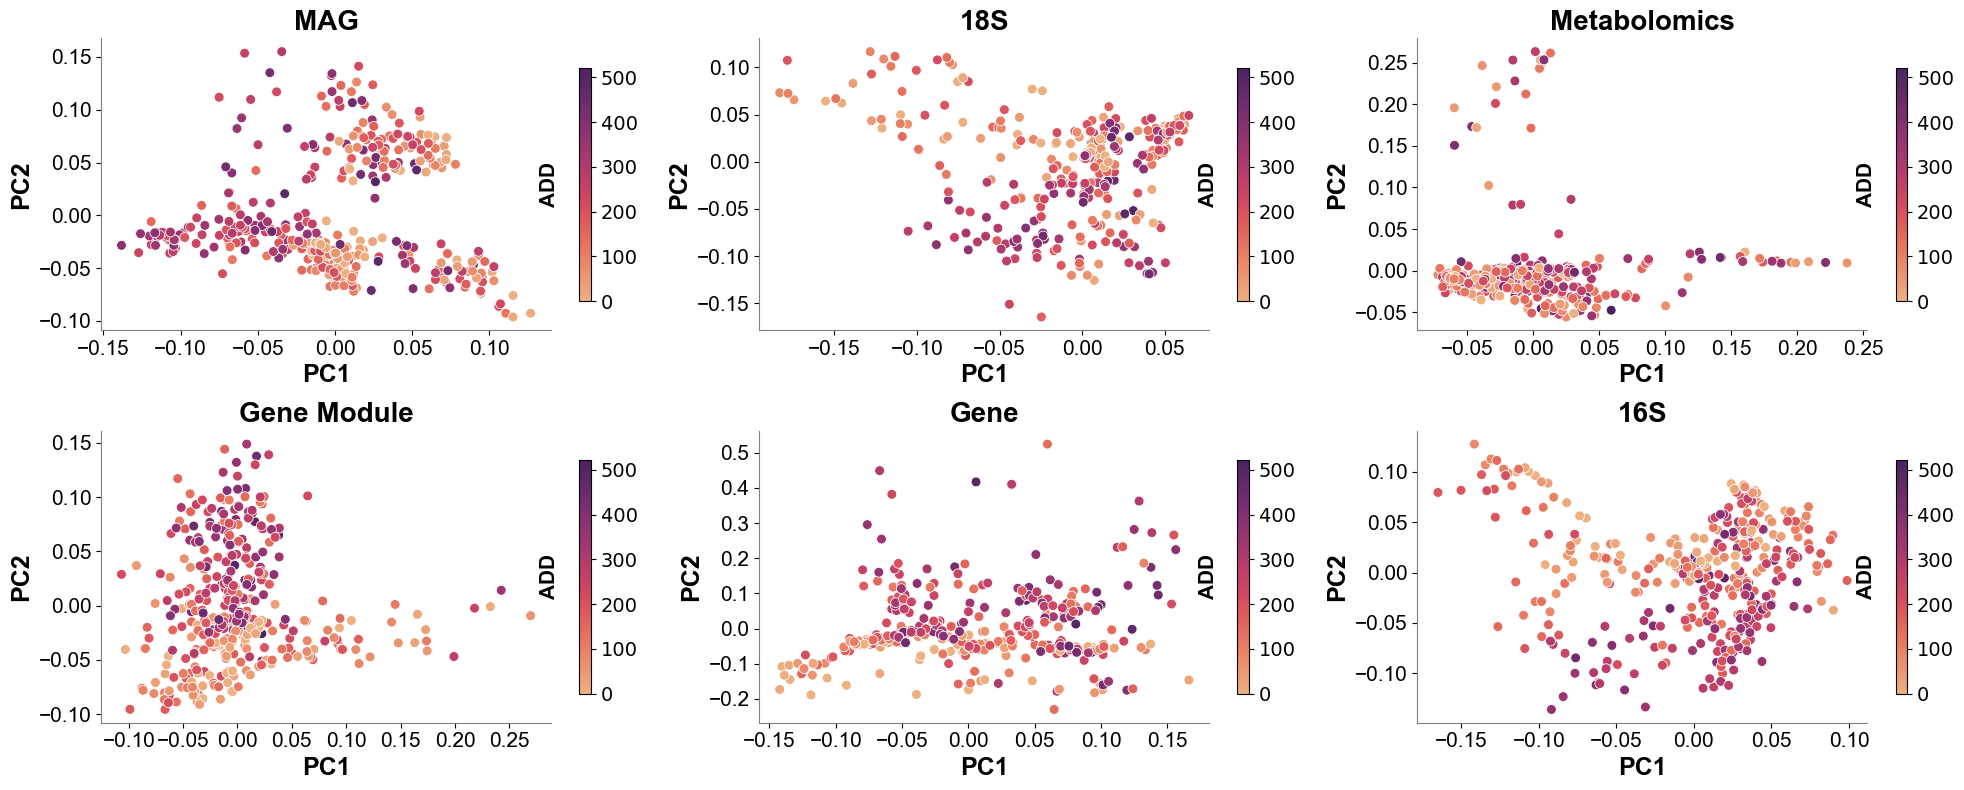

In [5]:
ordination_scatterplots(rpca_plots_, hue="add_0c", hue_order=None, 
                        cbar_label='ADD', x="PC1", y="PC2",
                        colorbar=True, point_size=50, title_= None,
                        palette=sns.color_palette("flare", as_cmap=True),
                        subplots=(2, 3), save_fig=False, figsize=(20, 8),
                        save_path=None)

### Fig S9

In [30]:
supp_pr_curve = pd.read_csv(f'{source_path}Fig_S9/Fig_S9_PR_curve_values.csv')
supp_pr_curve.head()

,dataset,method,recall,precision,precision_lower,precision_upper,mean_precision,sd_precision
0,microbiome,all features,1.000000,0.200000,0.180508,0.219492,0.972046,0.019492
1,microbiome,all features,0.988462,0.403454,0.383962,0.422945,0.972046,0.019492
2,microbiome,all features,0.980769,0.531250,0.511758,0.550742,0.972046,0.019492
3,microbiome,all features,0.980769,0.640704,0.621212,0.660195,0.972046,0.019492
4,microbiome,all features,0.976923,0.719547,0.700055,0.739038,0.972046,0.019492


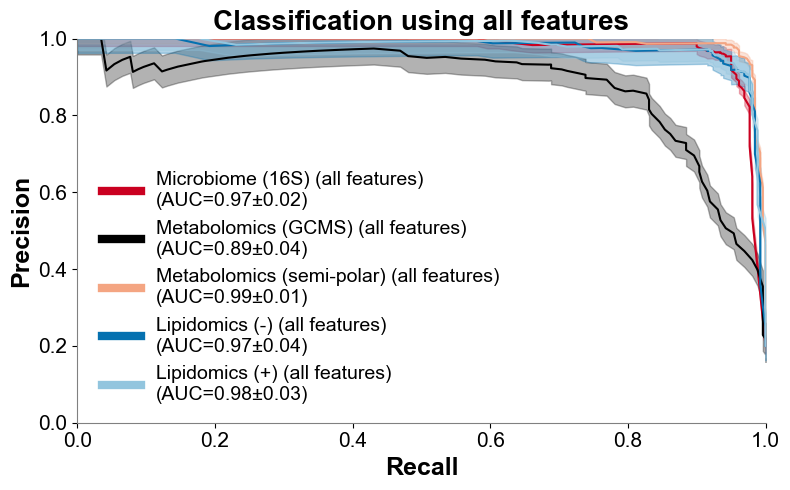

In [29]:
color_map = {('microbiome', 'all features'):'#ca0020',
             ('gcms', 'all features'):'black',
             ('lipid_polar', 'all features'):'#f4a582',
             ('lipid_neg', 'all features'):'#0571b0',
             ('lipid_pos', 'all features'):'#92c5de'}

pairs = [('microbiome', 'all features'), ('gcms', 'all features'),
        ('lipid_polar', 'all features'), ('lipid_neg', 'all features'), 
        ('lipid_pos', 'all features')]

label_ = {'gcms':'Metabolomics (GCMS)', 
         'lipid_neg':'Lipidomics (-)', 
         'lipid_polar':'Metabolomics (semi-polar)', 
         'lipid_pos':'Lipidomics (+)' ,
         'microbiome':'Microbiome (16S)',
         'all':'All omics'}

fig, ax = plt.subplots(1,1,figsize=(8, 5))
for pair in pairs:

    sub = supp_pr_curve[(supp_pr_curve['dataset'] == pair[0]) &
                        (supp_pr_curve['method'] == pair[1])].copy()
    mean_ap = sub['mean_precision'].iloc[0]
    sd_ap = sub['sd_precision'].iloc[0]
    
    ax.plot(sub['recall'], sub['precision'], c=color_map[pair],
            label='%s (%s)\n(AUC=%0.2f±%0.2f)' % (label_[pair[0]], pair[1],
                                                  mean_ap, sd_ap))
    ax.fill_between(sub['recall'], sub['precision_lower'],
                    sub['precision_upper'],
                    alpha=0.3, color=color_map[pair])
    
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel('Recall', color='black', weight='bold', 
              fontsize=18, fontname='Arial')
ax.set_ylabel('Precision', color='black', weight='bold', 
              fontsize=18, fontname='Arial')
ax.set_title('Classification using all features',
             color='black', weight='bold', 
             fontsize=20, fontname='Arial')
# fix backround
ax.set_facecolor('white')
ax.set_axisbelow(True)
sns.despine()
for child in ax.get_children():
    if isinstance(child, matplotlib.spines.Spine):
        child.set_color('grey')
for tick in ax.get_yticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(15)
for tick in ax.get_xticklabels():
    tick.set_fontproperties('arial')
    tick.set_color("black")
    tick.set_fontsize(15)
legend = ax.legend(loc=2, 
        bbox_to_anchor=(.01, .7),
        prop={'size':14, 'family':'Arial'}, 
        title="",
        fancybox=True, framealpha=.0,
        ncol=1, markerscale=5.5)
legend.get_title().set_fontsize('16')
# increase the line width in the legend 
for line in legend.get_lines()[:]:
    line.set_linewidth(6.0)
for line in legend.get_lines()[:]:
    line.set_linewidth(6.0)

plt.tight_layout()
plt.show()